# This notebook will be used to create a data preprocessing pipeline

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

data_good = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Goede_weg_tunnel_uni-2026-09-10_06-35-18\Accelerometer.csv")
data_bad = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Slechte_weg_pathe-2026-09-10_06-33-34\Accelerometer.csv")
print(data_good.head())
data_good.info()

                  time  seconds_elapsed         z         y         x
0  1789022118626398500         0.061398  0.316404  0.050293  0.111913
1  1789022118636323300         0.071323  0.336780  0.106358  0.264952
2  1789022118646248200         0.081248  0.053363  0.166461  0.333310
3  1789022118656173000         0.091173 -0.367505  0.249458  0.335399
4  1789022118666098000         0.101098 -0.932416  0.312662  0.403675
<class 'pandas.DataFrame'>
RangeIndex: 5216 entries, 0 to 5215
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             5216 non-null   int64  
 1   seconds_elapsed  5216 non-null   float64
 2   z                5216 non-null   float64
 3   y                5216 non-null   float64
 4   x                5216 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 203.9 KB


In [ ]:
data_good['dt'] = pd.to_datetime(data_good['time'], unit = 'ns')

In [ ]:
data_good.head()

,time,seconds_elapsed,z,y,x,dt
0,1789022118626398500,0.061398,0.316404,0.050293,0.111913,2026-09-10 06:35:18.626398500
1,1789022118636323300,0.071323,0.336780,0.106358,0.264952,2026-09-10 06:35:18.636323300
2,1789022118646248200,0.081248,0.053363,0.166461,0.333310,2026-09-10 06:35:18.646248200
3,1789022118656173000,0.091173,-0.367505,0.249458,0.335399,2026-09-10 06:35:18.656173000
4,1789022118666098000,0.101098,-0.932416,0.312662,0.403675,2026-09-10 06:35:18.666098000


In [ ]:
data_good.corr()

,time,seconds_elapsed,z,y,x,dt
time,1.000000,1.000000,0.003852,0.008754,-0.007890,1.000000
seconds_elapsed,1.000000,1.000000,0.003852,0.008754,-0.007890,1.000000
z,0.003852,0.003852,1.000000,-0.136641,-0.160302,0.003852
y,0.008754,0.008754,-0.136641,1.000000,-0.055622,0.008754
x,-0.007890,-0.007890,-0.160302,-0.055622,1.000000,-0.007890
dt,1.000000,1.000000,0.003852,0.008754,-0.007890,1.000000


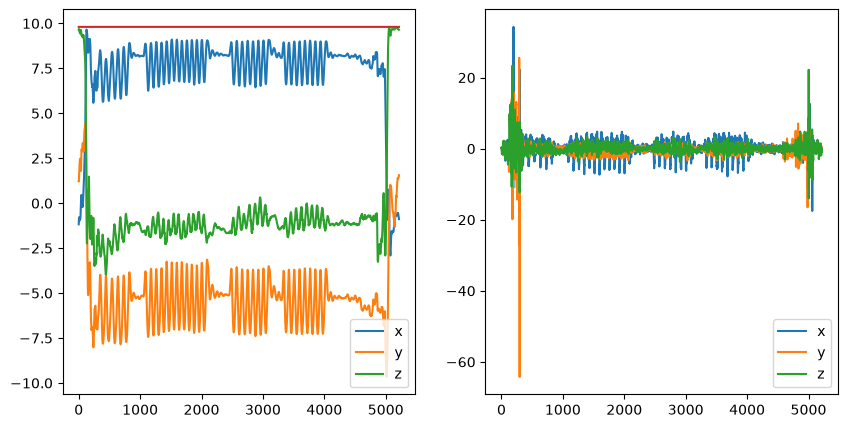

In [ ]:
good_gravity_df = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Goede_weg_tunnel_uni-2026-09-10_06-35-18\Gravity.csv")

total_gravity = np.sqrt(good_gravity_df['x']**2 + good_gravity_df['y']**2 + good_gravity_df['z']**2)
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].plot(good_gravity_df['x'])
ax[0].plot(good_gravity_df['y'])
ax[0].plot(good_gravity_df['z'])
ax[0].plot(total_gravity)
ax[0].legend(['x', 'y', 'z'])

ax[1].plot(data_good['x'])
ax[1].plot(data_good['y'])
ax[1].plot(data_good['z'])
ax[1].legend(['x', 'y', 'z'])

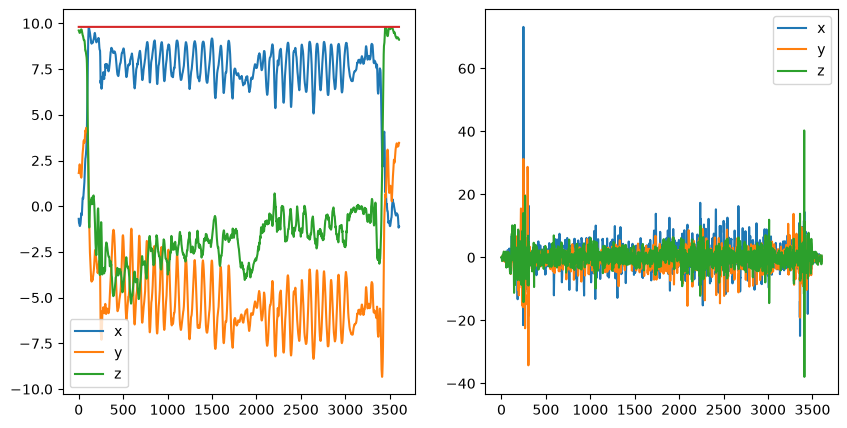

In [ ]:
bad_gravity_df = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Slechte_weg_pathe-2026-09-10_06-33-34\Gravity.csv")

total_gravity = np.sqrt(bad_gravity_df['x']**2 + bad_gravity_df['y']**2 + bad_gravity_df['z']**2)
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].plot(bad_gravity_df['x'])
ax[0].plot(bad_gravity_df['y'])
ax[0].plot(bad_gravity_df['z'])
ax[0].plot(total_gravity)
ax[0].legend(['x', 'y', 'z'])

ax[1].plot(data_bad['x'])
ax[1].plot(data_bad['y'])
ax[1].plot(data_bad['z'])
ax[1].legend(['x', 'y', 'z'])

In [ ]:
gyroscope = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Goede_weg_tunnel_uni-2026-09-10_06-35-18\Gyroscope.csv")
gyroscope.head()

,time,seconds_elapsed,z,y,x
0,1789022118626398500,0.061398,0.065210,-0.089339,-0.183565
1,1789022118636323300,0.071323,0.100029,0.104305,-0.109650
2,1789022118646248200,0.081248,0.131794,0.268017,-0.040012
3,1789022118656173000,0.091173,0.161726,0.354149,0.032681
4,1789022118666098000,0.101098,0.162337,0.323606,0.101098


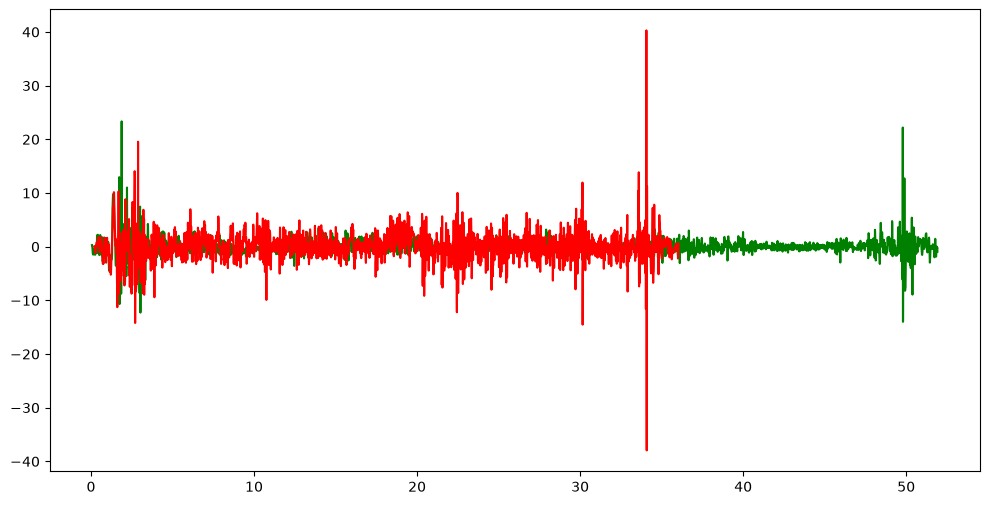

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data_good['seconds_elapsed'], data_good['z'], label='Good Road - Z-axis', color='green')
plt.plot(data_bad['seconds_elapsed'], data_bad['z'], label='Bad Road - Z-axis', color='red')

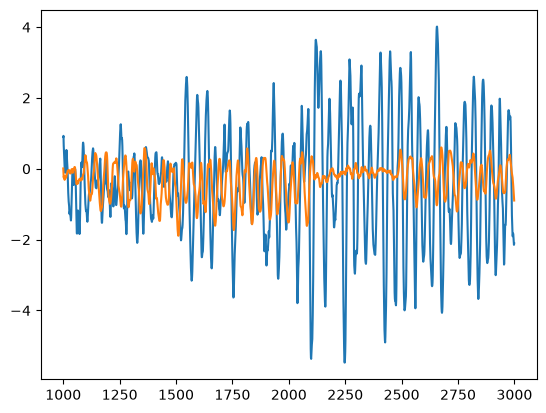

In [ ]:
window_size = 20
mean_signal_bad = data_bad['y'].iloc[1000:3000].rolling(window=window_size, min_periods=1).mean()
mean_signal_good = data_good['y'].iloc[1000:3000].rolling(window=window_size, min_periods=1).mean()

plt.plot(mean_signal_bad)
plt.plot(mean_signal_good)


In [ ]:
import numpy as np

def dci(acceleration_data):
    subset = acceleration_data.iloc[1000:3000]
    n = subset['y'][subset['y'] > 1].count()
    a = (subset['y']**2).sum()
    denom = np.sqrt((1/n) * a)
    dci = 1/denom

    return dci

print(dci(data_bad))
print(dci(data_good))


0.17647963235191846
0.2157833366504361


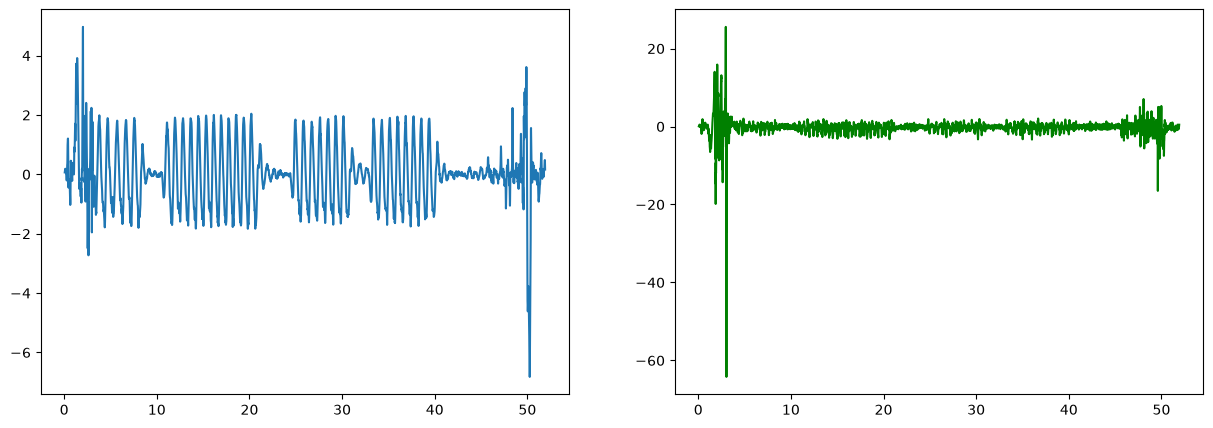

In [ ]:
_, ax = plt.subplots(ncols=2, figsize=(15,5))
ax[0].plot(gyroscope["seconds_elapsed"], gyroscope["z"])
ax[1].plot(data_good['seconds_elapsed'], data_good['y'], label='Good Road - y-axis', color='green')

In [ ]:
scaler = StandardScaler()
mean_signal_good = mean_signal_good.to_frame()
scaler.fit(mean_signal_good)

StandardScaler()

In [ ]:
mean_signal_bad = mean_signal_bad.to_frame()
scaler.fit(mean_signal_bad)

StandardScaler()

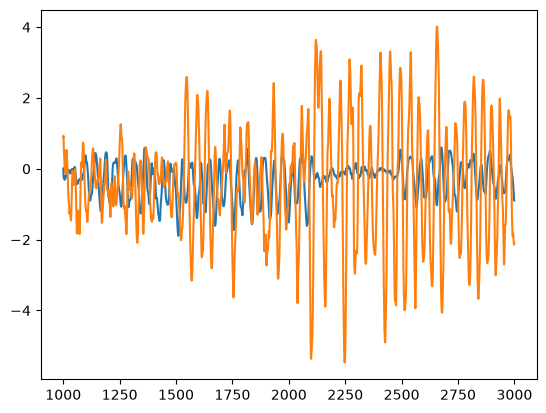

In [ ]:
plt.plot(mean_signal_good)
plt.plot(mean_signal_bad)

## Frequency analysis

(0.0, 0.35)

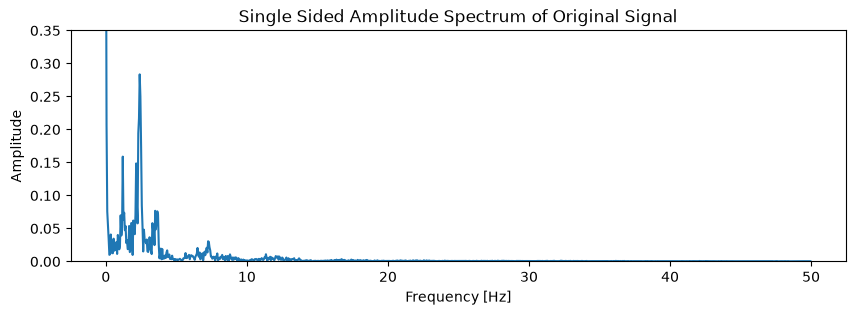

In [ ]:
# Perform data conditioning on the same signal function as before
from scipy.fft import fft, fftfreq

fs = 100 # Hz
N = len(mean_signal_good['y'])

zf = fft(mean_signal_good['y'])
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

(0.0, 0.35)

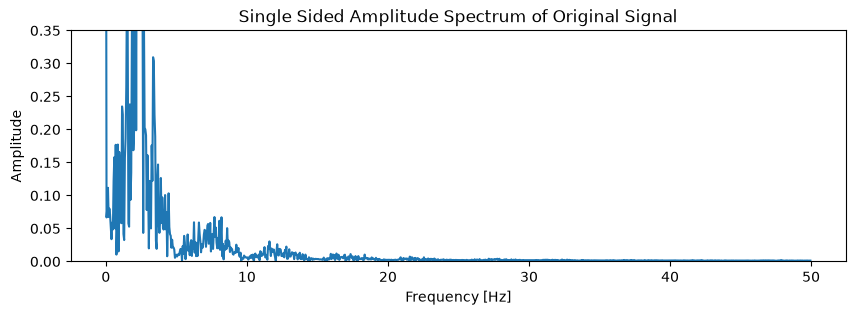

In [ ]:
fs = 100 # Hz
N = len(mean_signal_bad['y'])

zf = fft(mean_signal_bad['y'])
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

(-5.0, 5.0)

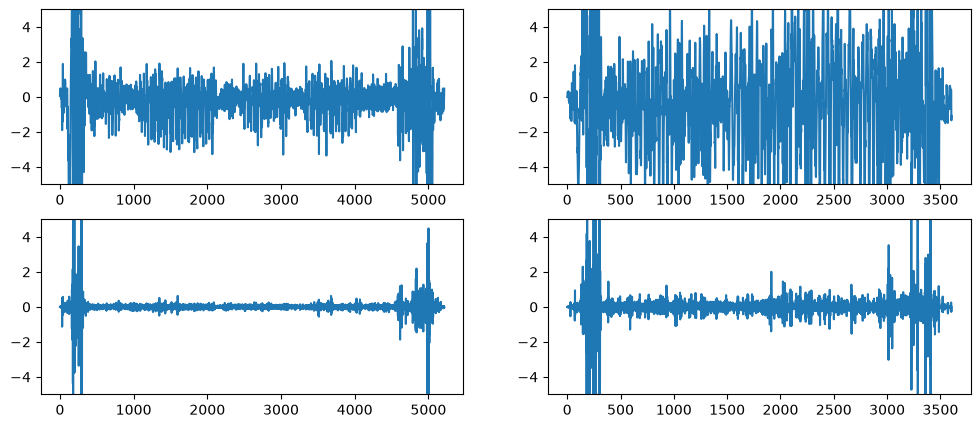

In [ ]:
from scipy import signal as sg
fs = 100 # Hz
nyq = fs/2
cutoff_frequency = 20

b, a = sg.butter(2, cutoff_frequency/nyq, btype='highpass')

filtered_good = sg.filtfilt(b, a, data_good['y'])
filtered_bad = sg.filtfilt(b, a, data_bad['y'])

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
ax[0, 0].plot(data_good['y'])
ax[0,0].set_ylim([-5, 5])

ax[0, 1].plot(data_bad['y'])
ax[0,1].set_ylim([-5, 5])

ax[1, 0].plot(filtered_good)
ax[1, 0].set_ylim([-5, 5])

ax[1, 1].plot(filtered_bad)
ax[1 ,1].set_ylim([-5, 5])



(-5.0, 5.0)

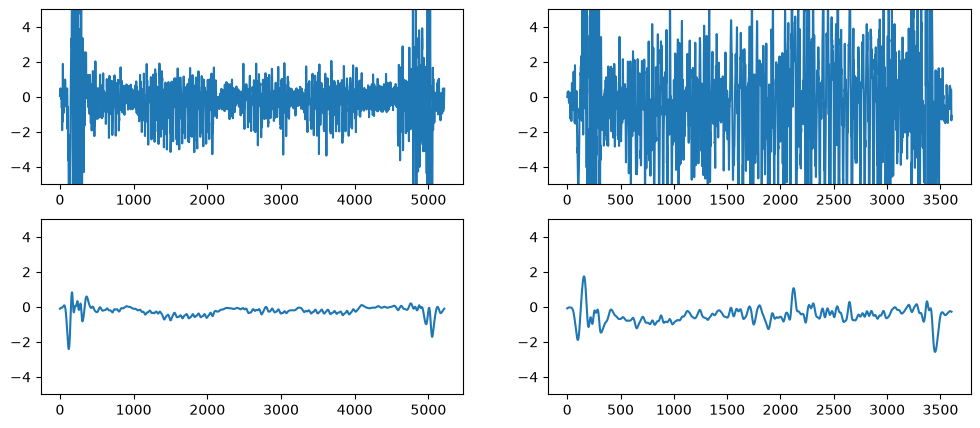

In [ ]:
fs = 100 # Hz
nyq = fs/2
cutoff_frequency = 1

b, a = sg.butter(2, cutoff_frequency/nyq, btype='low')

filtered_good = sg.filtfilt(b, a, data_good['y'])
filtered_bad = sg.filtfilt(b, a, data_bad['y'])

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
ax[0, 0].plot(data_good['y'])
ax[0,0].set_ylim([-5, 5])

ax[0, 1].plot(data_bad['y'])
ax[0,1].set_ylim([-5, 5])

ax[1, 0].plot(filtered_good)
ax[1, 0].set_ylim([-5, 5])

ax[1, 1].plot(filtered_bad)
ax[1 ,1].set_ylim([-5, 5])

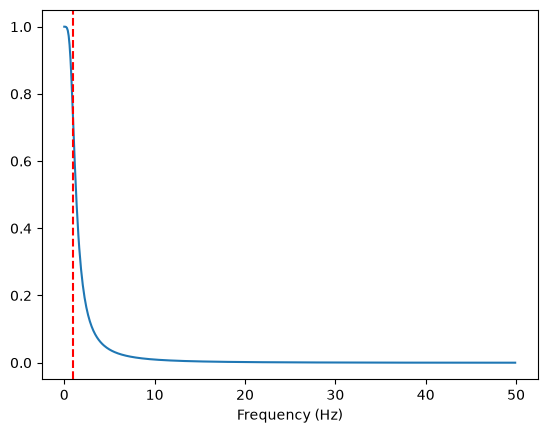

In [ ]:
from scipy.signal import freqz
w, h = freqz(b, a, fs=fs)
plt.plot(w, abs(h))
plt.xlabel('Frequency (Hz)')
plt.axvline(1, color='r', linestyle='--')

# PCA reduction

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit_transform(data_good["y"])

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.